**AI for Cell Image Analysis** <a id=0> </a>


<span style="font-size:20px">Lab Notebook 03</spam>

_Student name:_<font color = 'blue'> (input your name here)</font> <br>
_Student ID:_<font color = 'blue'> (input your student ID here)</font> <br>



<span style="font-size:30px"> Lab3. Introduction to Cell Segmentation</span>

**Author: [Zehua Zhao 赵泽华 zzh@stu.pku.edu.cn](mailto:zzh@stu.pku.edu.cn)**   <br>
*Assisted by: Claude Opus 4* <br>
Slightly modified by: Xiao Li

Cell segmentation is a fundamental task in biomedical image analysis that aims to accurately identify and delineate the boundaries of individual cells from microscopy images. This task is crucial for medical diagnosis, drug discovery, and biological research, including applications such as cancer detection, cell counting, and morphological analysis. Due to challenges like diverse cell morphologies, blurred boundaries, overlapping cells, and varying imaging conditions, traditional image processing methods often struggle to achieve satisfactory results. The emergence of deep learning, particularly networks like SAM and U-Net, has significantly improved the accuracy and efficiency of cell segmentation, making automated large-scale cell analysis possible.

---

## Task 0: Environment Setup

When running this program on Bohrium, choose image: </br>
**cellpose-sam:v01** </br>
from custom images.

You are recommended to connected to **GPU**: e.g., c3m4_1*NVIDIA T4.

### Install other dependencies

In [2]:
#Bohium online enviroment is ready. 
#When running on local machine, you may need to install the following pachages
#%pip install numpy
#%pip install matplotlib
#%pip install opencv-python
#%pip install requests

---

## Task 1: Cell Segmentation with OpenCV

OpenCV (Open Source Computer Vision Library) is an open-source computer vision and machine learning software library originally initiated by Intel in 1999. It provides over 2,500 optimized algorithms covering numerous areas including image processing, feature detection, object tracking, face recognition, and stereo vision. OpenCV supports multiple programming languages such as C++, Python, and Java, and runs on various platforms including Windows, Linux, Mac OS, iOS, and Android. With its rich functionality, efficient performance, and active community, OpenCV has become the most popular toolkit in the computer vision field, widely used in both academic research and industrial development.

### 1.1 Imports

In [3]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import requests

np.random.seed(42)

### 1.2 Load Image

Image downloaded and saved as ./cell_img07.png
Image shape: (333, 502)


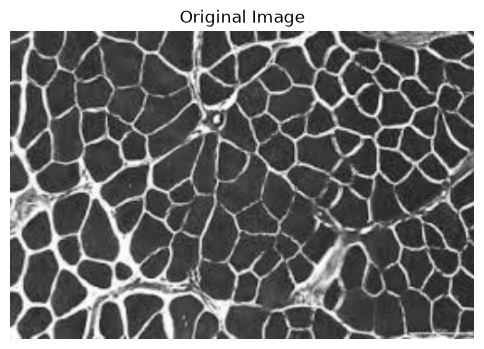

In [4]:
url = "https://www.cellpose.org/static/images/img07.png"
filename = "./cell_img07.png"

# Download the image if it doesn't exist

if not os.path.exists(filename):

    response = requests.get(url)
    with open(filename, 'wb') as f:
        f.write(response.content)
        print(f"Image downloaded and saved as {filename}")
else:
    print(f"Image already exists as {filename}")

# Load the image
image = cv2.imread(filename, cv2.IMREAD_GRAYSCALE)
print(f"Image shape: {image.shape}")

# Show the original image
plt.figure(figsize=(6, 4))
plt.imshow(image, cmap='gray')
plt.axis('off')
plt.title('Original Image')
plt.show()

### 1.3 Binarization

🔬 Binarization Using OpenCV for Biological Cell Segmentation

**Binarization** is an essential preprocessing step in biological image analysis. It converts a grayscale image into a binary format where **cells (foreground)** are separated from the **background**.

In this notebook, we use OpenCV’s `adaptiveThreshold` function to handle **non-uniform illumination**, which is common in microscopy images.

⚙️ **Parameter Details**

**`blockSize`**
- Size of the local region (a square window) around each pixel.
- **Must be an odd number** (e.g., 11, 21, 47).
- A larger block size uses more context to calculate the threshold:
  - **Larger blockSize** smooths out noise but may miss small or fine structures.
  - **Smaller blockSize** is more sensitive to local changes, capturing fine details, but can be noisy.

**`C`**
- A constant subtracted from the computed local mean (or weighted mean).
- This fine-tunes the threshold level:
  - **Negative `C`**: more aggressive binarization → more pixels classified as foreground.
  - **Positive `C`**: more conservative → fewer pixels classified as foreground.

Together, `blockSize` and `C` allow you to adapt the thresholding behavior to the specific needs of your image.


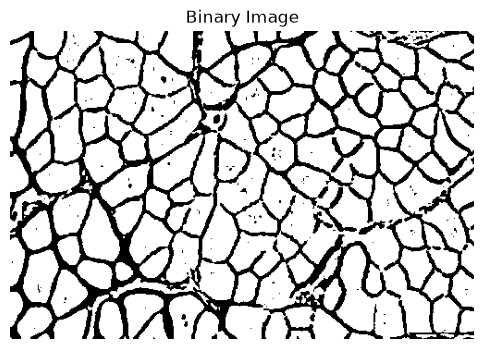

In [5]:
#blocksize sets the size of the pixel neighborhood a square to calculate the threshold 
#This should be an odd number
blocksize = 35
# C is a constant that will be subtracted from the calculated threshold value.
C = -5
# Apply adaptive thresholding
image_binary = cv2.adaptiveThreshold(image, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, blocksize, C)

# Show the binary image
plt.figure(figsize=(6, 4))
plt.imshow(image_binary, cmap='gray')
plt.axis('off')
plt.title('Binary Image')
plt.show()

<font face="Courier New">cv2.ADAPTIVE_THRESH_GAUSSIAN_C</font>: uses a weighted sum of neighborhood values (more accurate than mean).

<font face="Courier New">cv2.THRESH_BINARY_INV</font>: sets foreground pixels to white (255), background to black (0), which is typical in cell segmentation.

### 1.4 Morphological Operations

**Morphological operations** are techniques used to process binary images based on their shapes. These operations are especially useful for:

- Removing small noise
- Separating connected objects
- Filling small holes in objects

They work by probing an image with a small shape or template called a **structuring element** (or **kernel**).

In biological cell segmentation, morphological operations help clean up the binarized image by enhancing cell boundaries and eliminating background artifacts.


The **kernel** defines the shape and size of the neighborhood used for morphological operations.

<font face="Courier New">kernel = np.ones((3, 3), np.uint8)</font> This creates a _3×3 square kernel_ filled with ones.

It acts as a small window that slides over the image, affecting each pixel based on the local neighborhood.

A larger kernel (e.g., 5×5) will have a stronger effect, potentially removing or altering larger structures.

The kernel size must be chosen carefully:

- Too small: may not remove enough noise.

- Too large: may erode useful cell features.

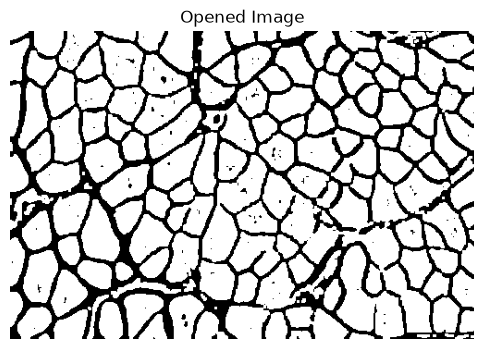

In [6]:
kernel = np.ones((3, 3), np.uint8)
# Perform morphological operations
image_opened = cv2.morphologyEx(image_binary, cv2.MORPH_OPEN, kernel)
# Show the opened image
plt.figure(figsize=(6, 4))
plt.imshow(image_opened, cmap='gray')
plt.axis('off')
plt.title('Opened Image')
plt.show()

<font face="Courier New">cv2.MORPH_OPEN</font> removes small white noise from the foreground while preserving the shape and size of larger objects (e.g., cells). </br>
Why use opening?</br>
In binarized cell images, small white dots or thin protrusions are often artifacts. </br>
Opening helps smooth cell edges and remove isolated foreground pixels that are likely not cells. </br>

### 1.5 Find Contours

In [7]:
# Find contours
contours, hierarchy = cv2.findContours(image_opened, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
# Filter contours based on area
min_area = 128
filtered_contours = [cnt for cnt in contours if cv2.contourArea(cnt) > min_area]

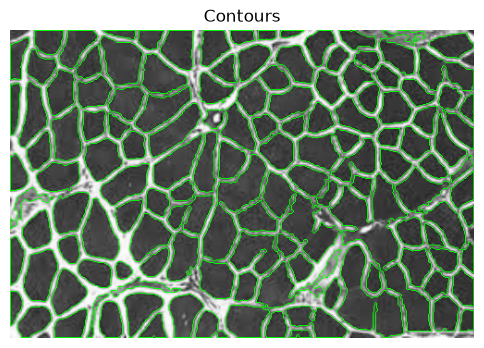

In [8]:
# Draw contours on a copy of the original image
image_contours = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
cv2.drawContours(image_contours, filtered_contours, -1, (0, 255, 0), 1)
# Show the contours
plt.figure(figsize=(6, 4))
plt.imshow(image_contours)
plt.axis('off')
plt.title('Contours')
plt.show()

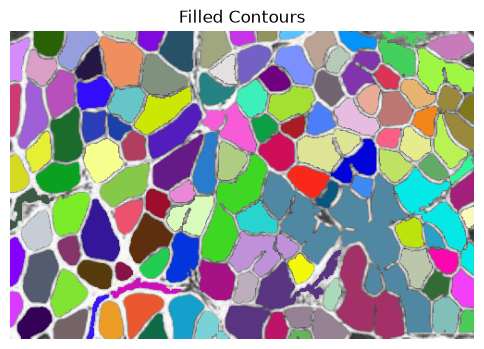

In [9]:
# Draw filled contours on a copy of the original image
image_filled = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
# Each cell is filled with a random color
for i, cnt in enumerate(filtered_contours):
    color = tuple(np.random.randint(0, 255, size=3).tolist())
    cv2.drawContours(image_filled, [cnt], -1, color, -1)
# Show the filled contours
plt.figure(figsize=(6, 4))
plt.imshow(image_filled)
plt.axis('off')
plt.title('Filled Contours')
plt.show()

### 1.6 Calculate Metrics

Number of detected cells: 123


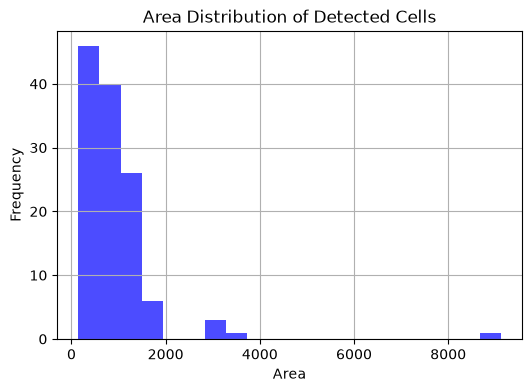

In [10]:
# Metrics
print(f"Number of detected cells: {len(filtered_contours)}")
# Calculate the area of each contour
areas = [cv2.contourArea(cnt) for cnt in filtered_contours]
plt.figure(figsize=(6, 4))
plt.hist(areas, bins=20, color='blue', alpha=0.7)
plt.title('Area Distribution of Detected Cells')
plt.xlabel('Area')
plt.ylabel('Frequency')
plt.grid()
plt.show()

**Record of Parameters and Results** </br>
- img07</br>
    blocksize = 35 </br>
    C = -5 </br>
    np.ones() = np.ones((3, 3), np.uint8) </br>
    min_area = 128 </br>
    and results:</br>
    total cell counts = 123 </br>
    segmentation quality(under, over, just right): just right </br>

- Try other images from https://www.cellpose.org. Adjust the blocksize, C, and np.ones(v,v) parameters to optimize the results. Record the optimal parameters and results. </br>
    - img22 </br>
      blocksize = 35 </br>
      C = -5 </br>
      np.ones() = np.ones((3, 3), np.uint8) </br>
      min_area = 128 </br>
      total cell counts = 52 </br>

    - choose one other image as you like: img00 </br>
      blocksize = 35 </br>
      C = -5 </br>
      np.ones() = np.ones((3, 3), np.uint8) </br>
      min_area = 128 </br>
      total cell counts = 74 </br>

### 1.7 img 22

Image already exists as ./cell_img22.png
Image shape: (172, 258)


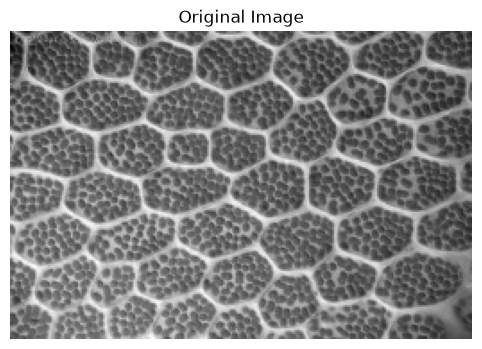

In [11]:
url = "https://www.cellpose.org/static/images/img22.png"
filename = "./cell_img22.png"

# Download the image if it doesn't exist

if not os.path.exists(filename):

    response = requests.get(url)
    with open(filename, 'wb') as f:
        f.write(response.content)
        print(f"Image downloaded and saved as {filename}")
else:
    print(f"Image already exists as {filename}")

# Load the image
image = cv2.imread(filename, cv2.IMREAD_GRAYSCALE)
print(f"Image shape: {image.shape}")

# Show the original image
plt.figure(figsize=(6, 4))
plt.imshow(image, cmap='gray')
plt.axis('off')
plt.title('Original Image')
plt.show()

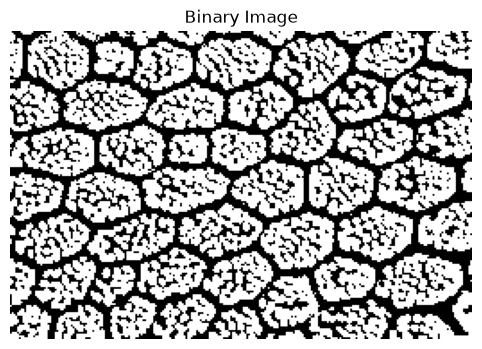

In [12]:
#blocksize sets the size of the pixel neighborhood a square to calculate the threshold 
#This should be an odd number
blocksize = 35
# C is a constant that will be subtracted from the calculated threshold value.
C = -5
# Apply adaptive thresholding
image_binary = cv2.adaptiveThreshold(image, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, blocksize, C)

# Show the binary image
plt.figure(figsize=(6, 4))
plt.imshow(image_binary, cmap='gray')
plt.axis('off')
plt.title('Binary Image')
plt.show()

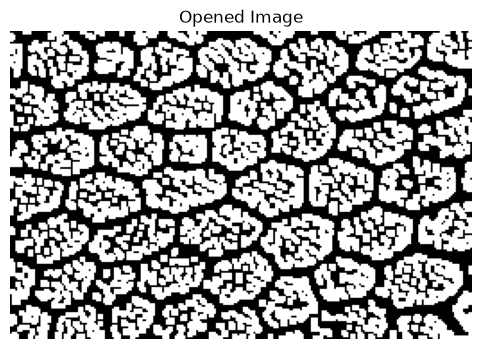

In [13]:
kernel = np.ones((3, 3), np.uint8)
# Perform morphological operations
image_opened = cv2.morphologyEx(image_binary, cv2.MORPH_OPEN, kernel)
# Show the opened image
plt.figure(figsize=(6, 4))
plt.imshow(image_opened, cmap='gray')
plt.axis('off')
plt.title('Opened Image')
plt.show()

In [14]:
# Find contours
contours, hierarchy = cv2.findContours(image_opened, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
# Filter contours based on area
min_area = 128
filtered_contours = [cnt for cnt in contours if cv2.contourArea(cnt) > min_area]

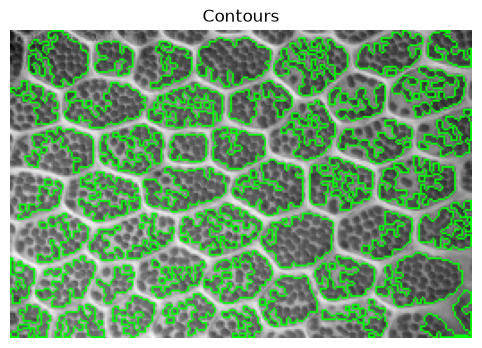

In [15]:
# Draw contours on a copy of the original image
image_contours = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
cv2.drawContours(image_contours, filtered_contours, -1, (0, 255, 0), 1)
# Show the contours
plt.figure(figsize=(6, 4))
plt.imshow(image_contours)
plt.axis('off')
plt.title('Contours')
plt.show()

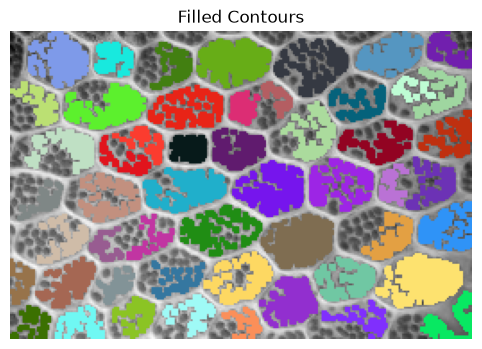

In [16]:
# Draw filled contours on a copy of the original image
image_filled = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
# Each cell is filled with a random color
for i, cnt in enumerate(filtered_contours):
    color = tuple(np.random.randint(0, 255, size=3).tolist())
    cv2.drawContours(image_filled, [cnt], -1, color, -1)
# Show the filled contours
plt.figure(figsize=(6, 4))
plt.imshow(image_filled)
plt.axis('off')
plt.title('Filled Contours')
plt.show()

Number of detected cells: 52


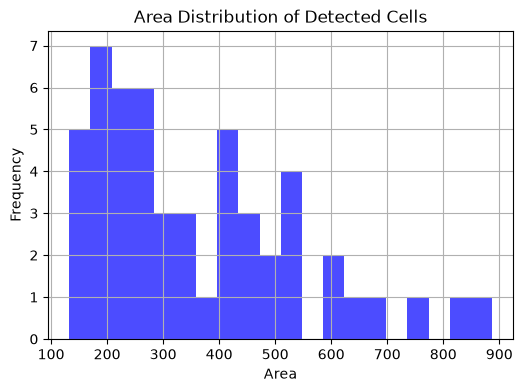

In [17]:
# Metrics
print(f"Number of detected cells: {len(filtered_contours)}")
# Calculate the area of each contour
areas = [cv2.contourArea(cnt) for cnt in filtered_contours]
plt.figure(figsize=(6, 4))
plt.hist(areas, bins=20, color='blue', alpha=0.7)
plt.title('Area Distribution of Detected Cells')
plt.xlabel('Area')
plt.ylabel('Frequency')
plt.grid()
plt.show()

### 1.8 colored

Image already exists as ./cell_img00.png
Image shape: (512, 512, 3)


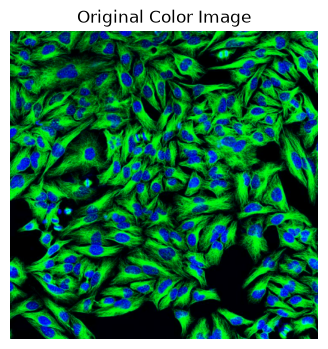

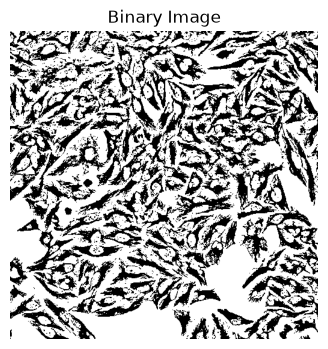

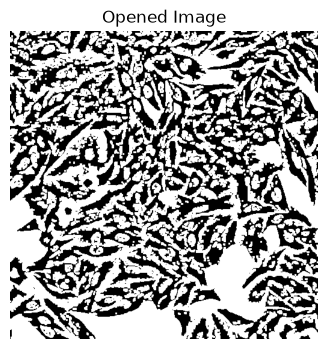

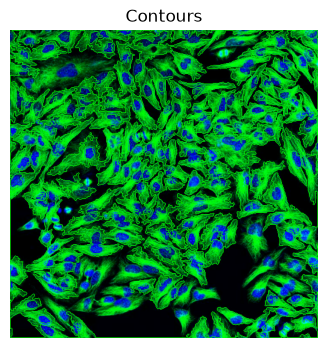

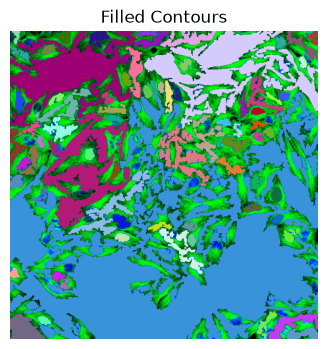

Number of detected cells: 74


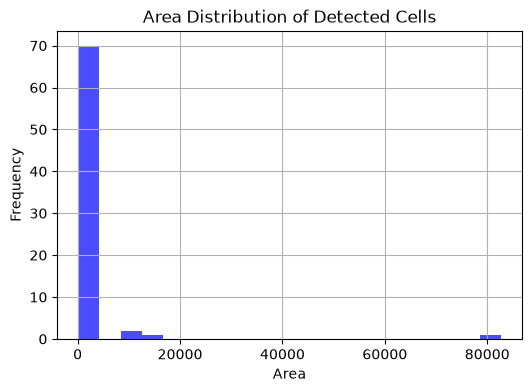

In [19]:
import os
import requests
import cv2
import numpy as np
import matplotlib.pyplot as plt

url = "https://www.cellpose.org/static/images/img00.png"
filename = "./cell_img00.png"

# Download the image if it doesn't exist
if not os.path.exists(filename):
    response = requests.get(url)
    with open(filename, 'wb') as f:
        f.write(response.content)
        print(f"Image downloaded and saved as {filename}")
else:
    print(f"Image already exists as {filename}")

# Load the image in color and convert it for display/processing
image_bgr = cv2.imread(filename, cv2.IMREAD_COLOR)
if image_bgr is None:
    raise FileNotFoundError(f"Failed to load image: {filename}")

print(f"Image shape: {image_bgr.shape}")
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
image_gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(6, 4))
plt.imshow(image_rgb)
plt.axis('off')
plt.title('Original Color Image')
plt.show()

# Adaptive thresholding on the grayscale version of the color image
blocksize = 35
C = -5
image_binary = cv2.adaptiveThreshold(
    image_gray,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY_INV,
    blocksize,
    C,
)

plt.figure(figsize=(6, 4))
plt.imshow(image_binary, cmap='gray')
plt.axis('off')
plt.title('Binary Image')
plt.show()

# Morphological opening removes small noisy regions
kernel = np.ones((3, 3), np.uint8)
image_opened = cv2.morphologyEx(image_binary, cv2.MORPH_OPEN, kernel)

plt.figure(figsize=(6, 4))
plt.imshow(image_opened, cmap='gray')
plt.axis('off')
plt.title('Opened Image')
plt.show()

# Find and filter contours
contours, hierarchy = cv2.findContours(image_opened, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
min_area = 128
filtered_contours = [cnt for cnt in contours if cv2.contourArea(cnt) > min_area]

# Draw contours on the original color image
image_contours = image_rgb.copy()
cv2.drawContours(image_contours, filtered_contours, -1, (0, 255, 0), 1)

plt.figure(figsize=(6, 4))
plt.imshow(image_contours)
plt.axis('off')
plt.title('Contours')
plt.show()

# Fill each detected cell with a random color
image_filled = image_rgb.copy()
for cnt in filtered_contours:
    color = tuple(np.random.randint(0, 255, size=3).tolist())
    cv2.drawContours(image_filled, [cnt], -1, color, -1)

plt.figure(figsize=(6, 4))
plt.imshow(image_filled)
plt.axis('off')
plt.title('Filled Contours')
plt.show()

# Metrics
print(f"Number of detected cells: {len(filtered_contours)}")
areas = [cv2.contourArea(cnt) for cnt in filtered_contours]

plt.figure(figsize=(6, 4))
plt.hist(areas, bins=20, color='blue', alpha=0.7)
plt.title('Area Distribution of Detected Cells')
plt.xlabel('Area')
plt.ylabel('Frequency')
plt.grid()
plt.show()


---

## Task 2: CellPose GUI Segmentation

Cellpose is a deep learning tool specifically designed for cell segmentation, developed by the Howard Hughes Medical Institute in 2020. Based on the U-Net architecture, it innovatively introduces a "gradient flow" approach that achieves precise segmentation by predicting vector fields pointing from each pixel toward cell centers. Cellpose can accurately segment cells of various morphologies even without training on specific cell types. The latest version of Cellpose utilizes the new CellPose-SAM model.

Cellpose is also available online at [CellPose](https://www.cellpose.org).

**TODO**: go online https://www.cellpose.org to use cellpose online service. Choose one cell image that you have used in Task 1 and another image that you didn't work on and process each of them with Cellpose-Sam online. Take a screenshot of your results.

### 2.1 Start CellPose GUI 

**Note**: This part needs to run on your local machine in order to use the GUI (graphical user interface).

**Create CellPose Conda Environment**

You need to install anaconda (miniconda recommended) on computer. Run the following commands in your terminal to create a new conda environment for CellPose:

```bash
conda create -n cellpose python=3.10 -y
conda activate cellpose
python -m pip install cellpose[gui] -i https://pypi.tuna.tsinghua.edu.cn/simple
```

PyTorch will be installed automatically with the CellPose package. If you need to install it separately with GPU support, you can use the following command:

```bash
pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118  # For CUDA 11.8 support
```


Run the following command in your terminal to start the CellPose GUI:

```bash
conda activate cellpose
python -m cellpose
```

### 2.2 Load Image

File > Load Image > Select ./cell_img07.png

### 2.3 Run CellPose

Click "Run CPSAM" to start the segmentation process. The model will be downloaded automatically if not already present.

### 2.4 Save Results

After the segmentation is complete, you can save the results by clicking "File > Save Masks as PNG/tif".

## Task 3: CellPose API

CellPose also provides Python API, making it accessible to biological researchers without computational backgrounds.

### 3.1 Imports

In [1]:
#Bohium online enviroment is ready. 
#When running on local machine, you may need to install the following pachages
#%pip install cellpose
#%pip install requests

In [2]:
import os
import numpy
import torch
import matplotlib.pyplot as plt
import requests
from cellpose import io, models, plot

### 3.2 Load Image

Image already exists as ./cell_img00.png
Image shape: (512, 512, 3)


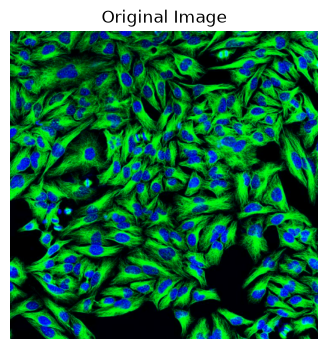

In [6]:
url = "https://www.cellpose.org/static/images/img00.png"
filename = "./cell_img00.png"
#TODO: change url to .../img22.png, and filename = "./cell_img22.png" and run task again

# Download the image if it doesn't exist
if not os.path.exists(filename):

    response = requests.get(url)
    with open(filename, 'wb') as f:
        f.write(response.content)
        print(f"Image downloaded and saved as {filename}")
else:
    print(f"Image already exists as {filename}")

# Load the image
image = io.imread(filename)
print(f"Image shape: {image.shape}")

# Show the original image
plt.figure(figsize=(6, 4))
plt.imshow(image, cmap='gray')
plt.axis('off')
plt.title('Original Image')
plt.show()


### 3.3 Segment Cells

In [ ]:
# Set model
gpu = torch.cuda.is_available()
print(f"Using GPU: {gpu}")
model = models.CellposeModel(gpu=gpu)

# Segment
masks, flows, styles = model.eval(image)

# Show the masks
fig = plt.figure(figsize=(12, 5))
plot.show_segmentation(fig, image, masks, flows[0])
plt.tight_layout()
plt.show()

Using GPU: False


 24%|██▍       | 287M/1.15G [08:36<3:58:22, 65.2kB/s] 

### 3.4 img 22

Image downloaded and saved as ./cell_img22.png
Image shape: (172, 258, 3)


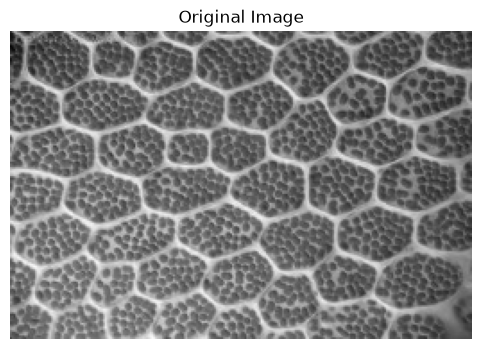

In [4]:
url = "https://www.cellpose.org/static/images/img22.png"
filename = "./cell_img22.png"
#TODO: change url to .../img22.png, and filename = "./cell_img22.png" and run task again

# Download the image if it doesn't exist
if not os.path.exists(filename):

    response = requests.get(url)
    with open(filename, 'wb') as f:
        f.write(response.content)
        print(f"Image downloaded and saved as {filename}")
else:
    print(f"Image already exists as {filename}")

# Load the image
image = io.imread(filename)
print(f"Image shape: {image.shape}")

# Show the original image
plt.figure(figsize=(6, 4))
plt.imshow(image, cmap='gray')
plt.axis('off')
plt.title('Original Image')
plt.show()


In [ ]:
# Set model
gpu = torch.cuda.is_available()
print(f"Using GPU: {gpu}")
model = models.CellposeModel(gpu=gpu)

# Segment
masks, flows, styles = model.eval(image)

# Show the masks
fig = plt.figure(figsize=(12, 5))
plot.show_segmentation(fig, image, masks, flows[0])
plt.tight_layout()
plt.show()

Using GPU: False


  2%|▏         | 21.0M/1.15G [00:48<22:03, 915kB/s]    

**结果对比**：
- OpenCV 对于分离较好的细胞效果还可以，但对参数比较敏感，遇到相邻或重叠的细胞时容易合并。
- Cellpose 更准确，更擅长分开粘连细胞、保留不规则边界,整体分割结果更可靠。

Notebook created by **[赵泽华 zzh@stu.pku.edu.cn](mailto:zzh@stu.pku.edu.cn)**</br>
Slightly modified by: Xiao Li